# Perovskite Energy Yield with Degradation
Predicts real-world operational lifetime ($T_{80}$, $T_{90,Agg}$) and hourly energy yield of a
single-junction perovskite solar cell using the combined **Arrhenius + power-law** degradation model of
Orooji et al. (2026), parameterised from the accelerated aging data of Zhao et al. (2022).

**Models covered:**
1. **Device-level CE degradation factor** — `perovskite_degradation_factor()` (D046, CsPbI₃)
2. **Energy yield with pvlib single-diode model** — `degraded_power_ratio()` computes hourly $P_{mp}$,
   aggregated power ratio $PR_{Agg}(t)$, and $T_{90,Agg}$.
3. **Multi-location comparison** — Golden CO, Miami FL, New York NY, with T₈₀ and T₉₀ thresholds.
4. **Multi-year projection** — tiling the meteorological year to find the T₈₀ crossing date.

**Key equations:**

$$k(T_i, I_i) = k_0 \cdot \exp\!\left(\frac{-E_a}{k_B T_i}\right) \cdot \left(\frac{I_i}{I_{ref}}\right)^{\!\gamma}$$

$$DF(i) = A_1 e^{-k_{fast} \cdot 1\text{h}} + A_2 e^{-k_{slow} \cdot 1\text{h}} + B
\qquad
DF_{total}(t) = \prod_{i=1}^{t} DF(i)$$

$$PR_{Agg}(t) = \frac{\sum_{i=1}^{t} P_{deg}(i)}{\sum_{i=1}^{t} P_{ref}(i)}$$

> **See also:** `05_scenario_perovskite_sequential.ipynb` — Siegler MAPbI₃ chemistry model
> and Scenario sequential job chaining.
> **See also:** `07_scenario_module_stack.ipynb` — full multi-layer module stack with moisture ingress.

**References:**
- Orooji et al. (2026) *EES Solar*. doi: 10.1039/d6el00021e
- Zhao et al. (2022) *Science* 377, 307–310. doi: 10.1126/science.abn5679

## 1. Imports and data

In [ ]:
import os
import json
import tempfile
import numpy as np
import pandas as pd
import pvdeg
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

REPO_ROOT = os.path.dirname(os.path.dirname(pvdeg.__file__))
TUTORIALS_DATA = os.path.join(REPO_ROOT, "tutorials", "data")

# Redirect all Scenario job folders to the system temp directory.
# Keeps the repo working directory free of pvd_job_* clutter.
pvdeg.config.SCENARIO_OUTPUT_PATH = tempfile.gettempdir()

# Lifetime threshold
# Change this to analyse a different degradation endpoint. Plots, prints, map colors will correspond to this setting e.g. 0.90 for T90.
T_THRESHOLD = 0.90
T_LABEL = f"T{int(T_THRESHOLD * 100)}"  # e.g. "T90" or "T80"

In [21]:
LOCATIONS = {
    "Golden, CO": ("psm4_golden.csv", "meta_golden.json"),
    "Miami, FL": ("psm4_miami.csv", "meta_miami.json"),
    "New York, NY": ("psm4_nyc.csv", "meta_nyc.json"),
}

all_weather, all_meta = {}, {}
for loc, (wf, mf) in LOCATIONS.items():
    df = pd.read_csv(
        os.path.join(TUTORIALS_DATA, wf),
        index_col=0,
        parse_dates=True,
    )
    df.index = df.index.map(lambda ts: ts.replace(year=2020))
    df = df.sort_index()
    with open(os.path.join(TUTORIALS_DATA, mf)) as _f:
        mt = json.load(_f)
    all_weather[loc], all_meta[loc] = df, mt
    print(f"  {loc}: {len(df)} rows  ({mt['latitude']:.2f}°N, {mt['longitude']:.2f}°E)")

# Single-location aliases used by the EY demonstration cells below
weather_df = all_weather["Golden, CO"]
meta = all_meta["Golden, CO"]
display_year = 2020

  Golden, CO: 8760 rows  (39.73°N, -105.18°E)
  Miami, FL: 8760 rows  (25.77°N, -80.18°E)
  New York, NY: 8760 rows  (40.65°N, -73.98°E)


---
## 2. Zhao / Orooji degradation parameters (D046)

The model is parameterised from the **uncapped CsPbI₃** device in Zhao et al. (2022),
which was aged at 35–110 °C under ~1200 W m⁻² continuous illumination.
Activation energies come directly from the Arrhenius plot (Fig. 3C of the paper):

| Parameter | Value | Meaning |
|-----------|-------|---------|
| $E_{a,fast}$ | 0.248 eV | Activation energy of the fast degradation process |
| $E_{a,slow}$ | 0.243 eV | Activation energy of the slow degradation process |
| $A_1$ | 0.25 | Amplitude of the fast exponential |
| $A_2$ | 0.70 | Amplitude of the slow exponential |
| $B$ | 0.05 | Residual stable fraction (long-term plateau) |
| $\gamma$ | 1.0 | Light-intensity exponent |
| $I_{ref}$ | 1200 W m⁻² | Reference irradiance of the aging experiment |

These are stored in `DegradationDatabase.json` entry **D046** and loaded below.

In [22]:
d046 = pvdeg.utilities.get_kinetics("D046")

print("D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)")
skip = {
    "DataEntryPerson",
    "DateEntered",
    "doi",
    "SourceTitle",
    "Authors",
    "Reference",
    "Material",
    "EquationType",
    "Comments",
}
for k, v in d046.items():
    if k not in skip:
        print(f"  {k}: {v}")

D046 — Zhao et al. 2022 (uncapped CsPbI₃, doi: 10.1126/science.abn5679)
  Ea_fast: 0.248
  Ea_slow: 0.243
  k0_fast: 0.56
  k0_slow: 0.48
  A1: 0.25
  A2: 0.7
  B: 0.05
  gamma: 1.0
  I_ref: 1200.0


---
## 3. Scenario pipeline — CE factor and module temperature

Three jobs run inside the Scenario pipeline. `degraded_power_ratio()` returns a `dict`
(which the Scenario pipeline does not store), so it is called directly afterwards with
the pipeline outputs.

| Step | Function | Output name | Depends on |
|------|----------|-------------|------------|
| 1 | `spectral.poa_irradiance` | `"poa"` | — |
| 2 | `temperature.module` | `"temp_mod"` | `poa` ← `"poa"` |
| 3 | `degradation.perovskite_degradation_factor` (D046) | `"ce_factor"` | `poa` ← `"poa"` |

In [23]:
scenarios = {}
for loc in LOCATIONS:
    sc = pvdeg.Scenario(
        name=f"ey-{loc.split(',')[0].lower().replace(' ', '-')}",
        weather_data=all_weather[loc],
        meta_data=all_meta[loc],
    )
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {
                "surface_tilt": abs(all_meta[loc]["latitude"]),
                "surface_azimuth": 180.0,
            },
        ),
        name="poa",
    )
    sc.addJob(
        func=pvdeg.temperature.module,
        name="temp_mod",
        depends_on={"poa": "poa"},
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.run()
    scenarios[loc] = sc
    print(f"  {loc}: CE@year-end = {sc.results['ce_factor'].iloc[-1]:.4f}")

# Golden, CO aliases for the EY cells below
s = scenarios["Golden, CO"]
ce_factor = s.results["ce_factor"]
poa_df = s.results["poa"]
temp_mod = s.results["temp_mod"]

The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  Golden, CO: CE@year-end = 0.9052
The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  Miami, FL: CE@year-end = 0.8799
The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
  New York, NY: CE@year-end = 0.9220


---
## 4. Energy yield with pvlib single-diode model

`degraded_power_ratio()` calls `pvlib.pvsystem.singlediode()` at each hourly timestep.
The photocurrent is scaled by the CE factor:

$$I_L^{deg}(t) = I_{sc,ref} \cdot \frac{G(t)}{G_{ref}} \cdot [1 + \alpha_{ISC}(T_{cell}(t) - T_{ref})] \cdot CE_{factor}(t)$$

Default diode parameters correspond to a generic ~20% PCE single-junction perovskite cell
(1 cm² area). Pass your own `I_sc_ref`, `I_0_ref`, `R_s`, `R_sh`, `n_diode` for a specific device.

In [24]:
ce_factor = s.results["ce_factor"]
poa_df = s.results["poa"]
temp_mod = s.results["temp_mod"]

# Call directly — degraded_power_ratio returns a dict, not a Series/DataFrame
ey = pvdeg.degradation.degraded_power_ratio(
    weather_df=weather_df,
    meta=meta,
    ce_factor=ce_factor,
    poa=poa_df,
    temp_cell=temp_mod,
)

PR_Agg = ey["PR_Agg"]
power_degraded = ey["power_degraded"]
power_reference = ey["power_reference"]

# Compute threshold crossing using T_THRESHOLD (set in the imports cell)
t_agg_idx = PR_Agg[PR_Agg <= T_THRESHOLD].index
if len(t_agg_idx):
    T_Agg_months = (
        (t_agg_idx[0] - PR_Agg.index[0]).total_seconds() / 3600 / (24 * 365.25 / 12)
    )
    print(f"{T_LABEL},Agg = {T_Agg_months:.1f} months")
else:
    end_pr = PR_Agg.iloc[-1]
    print(f"{T_LABEL},Agg not reached in 1 year  (PR_Agg at year-end = {end_pr:.4f})")
    print(f"CE factor at year-end = {ce_factor.iloc[-1]:.4f}")
    print(
        "Consistent with the paper's prediction of ~26–42 months depending on climate."
    )

T90,Agg not reached in 1 year  (PR_Agg at year-end = 0.9512)
CE factor at year-end = 0.9052
Consistent with the paper's prediction of ~26–42 months depending on climate.


Text(0.5, 1.01, 'Zhao/Orooji D046  |  Golden PR_Agg = 0.9512 at year-end')

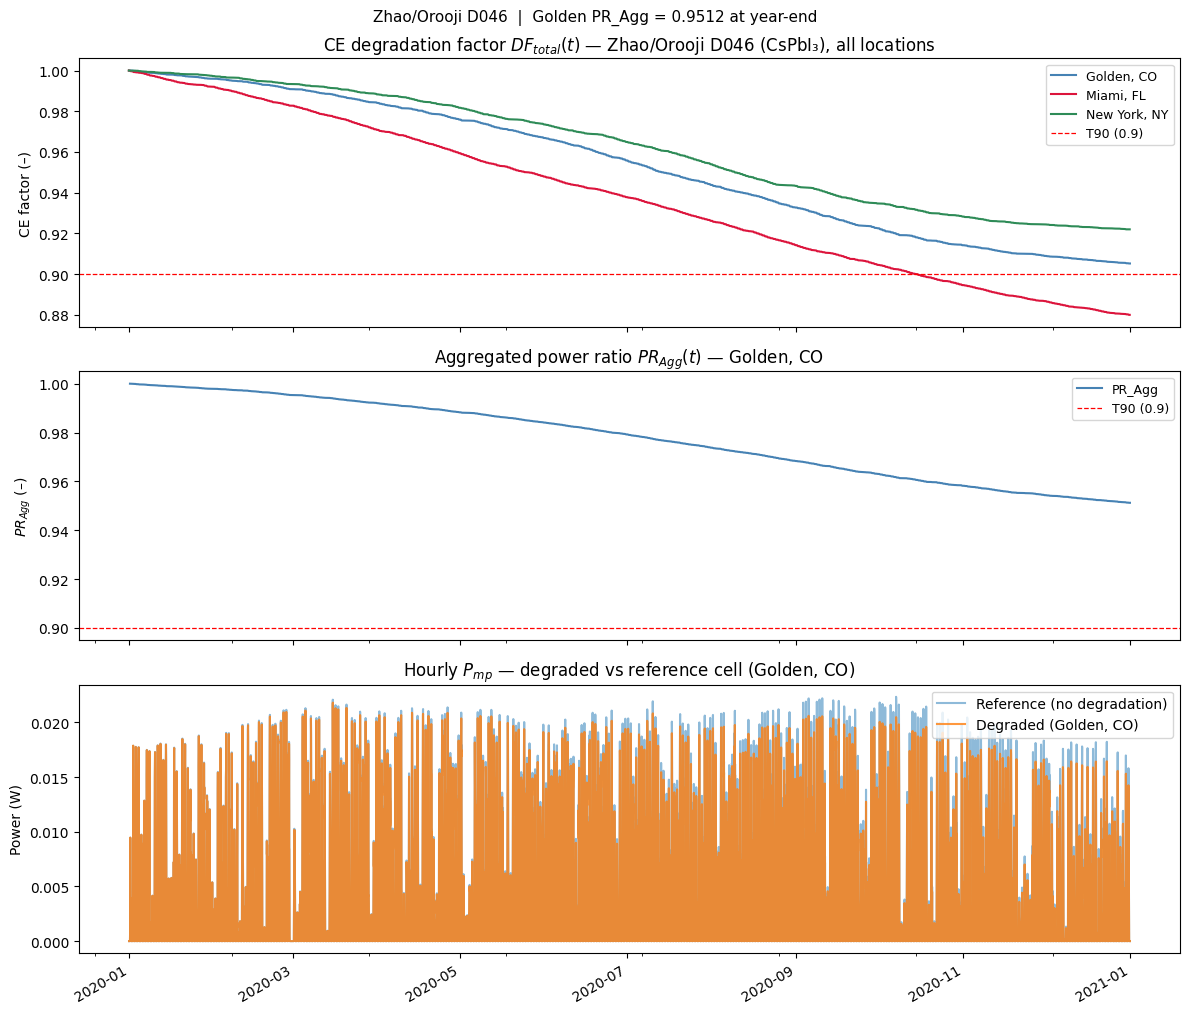

In [25]:
_colors = {
    "Golden, CO": "steelblue",
    "Miami, FL": "crimson",
    "New York, NY": "seagreen",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: CE degradation factor — all locations + threshold line
for loc, sc in scenarios.items():
    sc.results["ce_factor"].plot(ax=axes[0], label=loc, color=_colors[loc])
axes[0].axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
axes[0].set_ylabel("CE factor (–)")
axes[0].set_title(
    f"CE degradation factor $DF_{{total}}(t)$ — Zhao/Orooji D046 (CsPbI₃), all locations"
)
axes[0].legend(fontsize=9, loc="upper right")

# Panel 2: Aggregated power ratio — Golden, CO
PR_Agg.plot(ax=axes[1], color="steelblue")
axes[1].axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
axes[1].set_ylabel("$PR_{Agg}$ (–)")
axes[1].set_title(f"Aggregated power ratio $PR_{{Agg}}(t)$ — Golden, CO")
axes[1].legend(fontsize=9)

# Panel 3: Hourly power — degraded vs reference, Golden, CO
power_reference.plot(ax=axes[2], label="Reference (no degradation)", alpha=0.5)
power_degraded.plot(ax=axes[2], label="Degraded (Golden, CO)", alpha=0.8)
axes[2].set_ylabel("Power (W)")
axes[2].set_title("Hourly $P_{mp}$ — degraded vs reference cell (Golden, CO)")
axes[2].legend()

fig.tight_layout()
plt.suptitle(
    f"Zhao/Orooji D046  |  Golden PR_Agg = {PR_Agg.iloc[-1]:.4f} at year-end",
    y=1.01,
    fontsize=11,
)

---
## 5. Multi-year lifetime projection — finding the threshold crossing

One year of data is not enough to cross the `T_THRESHOLD` at any location. The standard approach
is to **tile** the same meteorological year across N years, which matches the methodology of
Orooji et al. (2026). The running product in `perovskite_degradation_factor()` accumulates
continuously, so the full N-year series is passed as a single concatenated input.


In [26]:
N_YEARS = 3  # increase if no location reaches T_THRESHOLD within the window


def make_multiyear(df, n_years, start_year=2020):
    """Tile a 1-year weather DataFrame across n_years by shifting the year index."""
    frames = []
    for y in range(n_years):
        yr = start_year + y
        f = df.copy()
        f.index = f.index.map(lambda ts, _yr=yr: ts.replace(year=_yr))
        frames.append(f)
    return pd.concat(frames).sort_index()


def run_ce_multiyear(wdf, mt, n_years=N_YEARS):
    """Run POA → CE factor on tiled N-year weather (no EY calculation).

    Passes explicit tilt (|latitude|) and south-facing azimuth (180°) to suppress
    the poa_irradiance default-assumption warning.
    Job folders go to pvdeg.config.SCENARIO_OUTPUT_PATH (set in the imports cell).
    """
    wdf_ny = make_multiyear(wdf, n_years)
    tilt = abs(mt["latitude"])
    sc = pvdeg.Scenario(name="ce-multiyear", weather_data=wdf_ny, meta_data=mt)
    sc.addJob(
        func=(
            pvdeg.spectral.poa_irradiance,
            {
                "surface_tilt": tilt,
                "surface_azimuth": 180.0,
            },
        ),
        name="poa",
    )
    sc.addJob(
        func=(pvdeg.degradation.perovskite_degradation_factor, {"parameters": d046}),
        name="ce_factor",
        depends_on={"poa": "poa"},
    )
    sc.run()
    return sc.results["ce_factor"]


print(
    f"Running {N_YEARS}-year CE projection for all locations  (threshold = {T_LABEL})..."
)
ce_multiyear = {}
for loc in LOCATIONS:
    print(f"  {loc}...", end="  ")
    ce_multiyear[loc] = run_ce_multiyear(all_weather[loc], all_meta[loc])
    t_idx = ce_multiyear[loc][ce_multiyear[loc] <= T_THRESHOLD].index
    if len(t_idx):
        t_months = (t_idx[0] - ce_multiyear[loc].index[0]).days / 30.44
        print(f"{T_LABEL} at {t_months:.1f} months")
    else:
        print(f"{T_LABEL} not reached in {N_YEARS} years")

Running 3-year CE projection for all locations  (threshold = T90)...
  Golden, CO...  The array surface_tilt angle was not provided, therefore the latitude of  39.7 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 13.4 months
  Miami, FL...  The array surface_tilt angle was not provided, therefore the latitude of  25.8 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 9.4 months
  New York, NY...  The array surface_tilt angle was not provided, therefore the latitude of  40.6 was used.
The array azimuth was not provided, therefore an azimuth of  180.0 was used.
T90 at 16.5 months


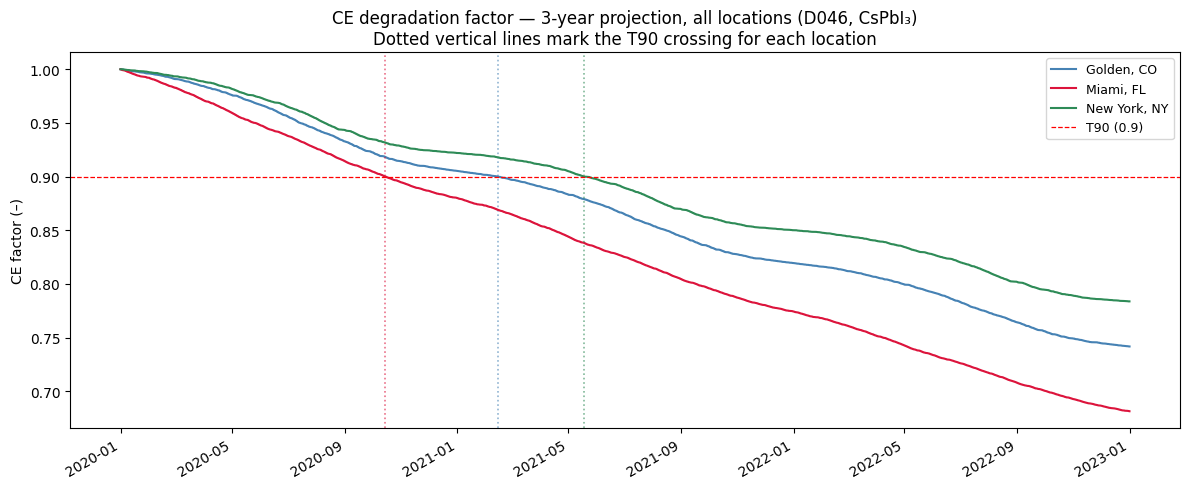

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

for loc, ce in ce_multiyear.items():
    ce.plot(ax=ax, label=loc, color=_colors[loc])
    # Mark the first threshold crossing with a dotted vertical line
    t_idx = ce[ce <= T_THRESHOLD].index
    if len(t_idx):
        ax.axvline(
            t_idx[0], color=_colors[loc], linestyle=":", alpha=0.6, linewidth=1.2
        )

ax.axhline(
    T_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=0.9,
    label=f"{T_LABEL} ({T_THRESHOLD})",
)
ax.set_ylabel("CE factor (–)")
ax.set_title(
    f"CE degradation factor — {N_YEARS}-year projection, all locations (D046, CsPbI₃)\n"
    f"Dotted vertical lines mark the {T_LABEL} crossing for each location"
)
ax.legend(fontsize=9)
fig.tight_layout()

---
## 6. Lifetime map — US state choropleth via NSRDB PSM4

Each state is coloured by how many months it takes until the **cumulative energy yield**
(`PR_Agg`) falls below `T_THRESHOLD` (default 0.90 → T₉₀), under the D046 (CsPbI₃)
Zhao/Orooji kinetics using a 3-year tiled PSM4 TMY.

This is the energy-yield answer to "when have I lost `(1 − T_THRESHOLD) × 100 %` of my
investment?" — the same metric reported by Orooji et al. (2026).

> **Why not DF_total?**
> $DF_{total}$ is the *instantaneous* CE at a given hour (device-level metric).
> It crosses the threshold much earlier than $PR_{Agg}$ because it ignores all the energy
> already delivered when the device was at high efficiency.
> Phoenix example (T₉₀): $DF_{total}$ ≈ 7–8 months vs $PR_{Agg}$ ≈ 24–28 months.
> Both are stored in `df_map`; hover over a state to compare them.

**Colour scale:** green = long lifetime (good), red = short lifetime (bad).


In [28]:
# ── Fetch lifetime data for all 50 US states via NSRDB PSM4 API ──────────────
# Get a free key at https://developer.nrel.gov/signup/

NREL_API_KEY = "DEMO_API_KEY"
NREL_EMAIL = "DEMO_EMAIL"

# abbr: (api_lat, api_lon, label, centre_lat, centre_lon)
STATES = {
    "AL": (32.36, -86.30, "Montgomery, AL", 32.8, -86.8),
    "AK": (61.22, -149.90, "Anchorage, AK", 64.2, -153.0),
    "AZ": (33.45, -112.07, "Phoenix, AZ", 34.3, -111.1),
    "AR": (34.74, -92.33, "Little Rock, AR", 34.8, -92.2),
    "CA": (34.05, -118.24, "Los Angeles, CA", 37.2, -119.5),
    "CO": (39.73, -104.98, "Denver, CO", 39.0, -105.5),
    "CT": (41.76, -72.68, "Hartford, CT", 41.6, -72.7),
    "DE": (39.16, -75.52, "Dover, DE", 39.0, -75.5),
    "FL": (25.77, -80.19, "Miami, FL", 27.8, -81.6),
    "GA": (33.75, -84.39, "Atlanta, GA", 32.7, -83.4),
    "HI": (21.31, -157.86, "Honolulu, HI", 20.5, -157.3),
    "ID": (43.61, -116.20, "Boise, ID", 44.4, -114.6),
    "IL": (41.88, -87.63, "Chicago, IL", 40.0, -89.2),
    "IN": (39.77, -86.16, "Indianapolis, IN", 40.3, -86.1),
    "IA": (41.59, -93.62, "Des Moines, IA", 42.0, -93.5),
    "KS": (39.05, -95.69, "Topeka, KS", 38.5, -98.4),
    "KY": (38.25, -85.76, "Louisville, KY", 37.5, -85.3),
    "LA": (29.95, -90.07, "New Orleans, LA", 31.1, -91.8),
    "ME": (44.32, -69.77, "Augusta, ME", 45.4, -69.2),
    "MD": (38.97, -76.49, "Annapolis, MD", 39.0, -76.7),
    "MA": (42.36, -71.06, "Boston, MA", 42.3, -71.8),
    "MI": (42.73, -84.56, "Lansing, MI", 44.3, -85.4),
    "MN": (44.94, -93.09, "Minneapolis, MN", 46.4, -93.1),
    "MS": (32.30, -90.18, "Jackson, MS", 32.7, -89.7),
    "MO": (38.57, -92.17, "Jefferson City, MO", 38.4, -92.5),
    "MT": (46.60, -112.02, "Helena, MT", 47.0, -110.4),
    "NE": (40.81, -96.68, "Lincoln, NE", 41.5, -99.9),
    "NV": (36.17, -115.14, "Las Vegas, NV", 39.3, -116.6),
    "NH": (43.21, -71.54, "Concord, NH", 43.7, -71.6),
    "NJ": (40.22, -74.76, "Trenton, NJ", 40.1, -74.5),
    "NM": (35.67, -105.96, "Santa Fe, NM", 34.4, -106.1),
    "NY": (40.71, -74.01, "New York, NY", 42.9, -75.6),
    "NC": (35.78, -78.64, "Raleigh, NC", 35.5, -79.4),
    "ND": (46.81, -100.78, "Bismarck, ND", 47.5, -100.5),
    "OH": (39.96, -82.99, "Columbus, OH", 40.4, -82.8),
    "OK": (35.47, -97.52, "Oklahoma City, OK", 35.6, -97.5),
    "OR": (44.94, -123.03, "Salem, OR", 44.1, -120.5),
    "PA": (40.27, -76.88, "Harrisburg, PA", 40.9, -77.8),
    "RI": (41.82, -71.42, "Providence, RI", 41.7, -71.5),
    "SC": (34.00, -81.03, "Columbia, SC", 33.9, -80.9),
    "SD": (44.37, -100.35, "Pierre, SD", 44.4, -100.2),
    "TN": (36.16, -86.78, "Nashville, TN", 35.9, -86.4),
    "TX": (30.27, -97.74, "Austin, TX", 31.5, -99.3),
    "UT": (40.76, -111.89, "Salt Lake City, UT", 39.4, -111.1),
    "VT": (44.26, -72.58, "Montpelier, VT", 44.0, -72.7),
    "VA": (37.54, -77.43, "Richmond, VA", 37.5, -78.9),
    "WA": (47.04, -122.90, "Olympia, WA", 47.4, -120.6),
    "WV": (38.35, -81.63, "Charleston, WV", 38.6, -80.6),
    "WI": (43.07, -89.40, "Madison, WI", 44.3, -89.8),
    "WY": (41.14, -104.82, "Cheyenne, WY", 43.0, -107.6),
}

map_data = []
for abbr, (lat, lon, label, clat, clon) in STATES.items():
    try:
        wdf, mt = pvdeg.weather.get(
            database="PSM4",
            id=(lat, lon),
            api_key=NREL_API_KEY,
            email=NREL_EMAIL,
            year="tmy",
            map_variables=True,
        )
        wdf.index = wdf.index.map(lambda ts: ts.replace(year=2020))
        wdf = wdf.sort_index()
        tilt = abs(mt["latitude"])  # latitude-tilt, south-facing — passed explicitly

        # ── CE factor (DF_total) threshold crossing — device-level ───────────
        ce = run_ce_multiyear(wdf, mt)
        t_df_idx = ce[ce <= T_THRESHOLD].index
        t_df_m = (t_df_idx[0] - ce.index[0]).days / 30.44 if len(t_df_idx) else None

        # ── PR_Agg threshold crossing — cumulative energy-yield metric ────────
        wdf_ny = make_multiyear(wdf, N_YEARS)
        sc_s = pvdeg.Scenario(name=f"ey-{abbr}", weather_data=wdf_ny, meta_data=mt)
        sc_s.addJob(
            func=(
                pvdeg.spectral.poa_irradiance,
                {
                    "surface_tilt": tilt,
                    "surface_azimuth": 180.0,
                },
            ),
            name="poa",
        )
        sc_s.addJob(
            func=pvdeg.temperature.module, name="temp_mod", depends_on={"poa": "poa"}
        )
        sc_s.addJob(
            func=(
                pvdeg.degradation.perovskite_degradation_factor,
                {"parameters": d046},
            ),
            name="ce_factor",
            depends_on={"poa": "poa"},
        )
        sc_s.run()
        ey_s = pvdeg.degradation.degraded_power_ratio(
            weather_df=wdf_ny,
            meta=mt,
            ce_factor=sc_s.results["ce_factor"],
            poa=sc_s.results["poa"],
            temp_cell=sc_s.results["temp_mod"],
        )
        pr_s = ey_s["PR_Agg"]
        t_pr_idx = pr_s[pr_s <= T_THRESHOLD].index
        t_pr_m = (t_pr_idx[0] - pr_s.index[0]).days / 30.44 if len(t_pr_idx) else None

        map_data.append(
            {
                "state": abbr,
                "location": label,
                "centre_lat": clat,
                "centre_lon": clon,
                "T_months": round(t_pr_m, 1) if t_pr_m is not None else None,
                "T_DF_months": round(t_df_m, 1) if t_df_m is not None else None,
            }
        )
        t_str = (
            f"{t_pr_m:.1f} mo (PR_Agg)  /  {t_df_m:.1f} mo (DF)"
            if t_pr_m
            else f">{N_YEARS}y"
        )
        print(f"  {abbr}: {T_LABEL} = {t_str}")
    except Exception as exc:
        print(f"  {abbr}: FAILED — {exc}")

df_map = pd.DataFrame(map_data)
print(f"\nFetched {len(df_map)} / {len(STATES)} states successfully.")
print(
    f"Map colour = PR_Agg {T_LABEL}  (energy-yield metric, consistent with Orooji et al.)"
)

  AL: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  AK: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  AZ: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  AR: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  CA: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  CO: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  CT: FAILED — Error Code,Error Message
"API_KEY_INVALID","An invalid api_key was supplied. Get one at https://developer.nrel.gov/signup/"
  DE: FAILED — Error Code,E

In [29]:
# ── Plot: PR_Agg lifetime choropleth with state abbreviation labels ───────────
# Re-run this cell freely to adjust styling without re-fetching API data.
# Colour = PR_Agg threshold (T_THRESHOLD, set in the imports cell).
# Hover also shows DF_total for comparison (device-level vs energy-yield metric).

if df_map.empty:
    print("No data in df_map — run the cell above first with valid API credentials.")
else:
    fig_map = px.choropleth(
        df_map,
        locations="state",
        locationmode="USA-states",
        color="T_months",
        scope="usa",
        hover_name="location",
        hover_data={
            "state": False,
            "T_months": True,
            "T_DF_months": True,
        },
        color_continuous_scale="RdYlGn",
        labels={
            "T_months": f"PR_Agg {T_LABEL} (months)",
            "T_DF_months": f"DF_total {T_LABEL} (months)",
        },
        title=(
            f"Energy-yield {T_LABEL} by US state  (PR_Agg < {T_THRESHOLD})<br>"
            f"<sup>D046 (CsPbI₃), {N_YEARS}-year tiled PSM4 TMY — "
            f"hover for DF_total {T_LABEL}</sup>"
        ),
    )

    labelled = df_map[df_map["T_months"].notna()]
    fig_map.add_trace(
        go.Scattergeo(
            lat=labelled["centre_lat"].tolist(),
            lon=labelled["centre_lon"].tolist(),
            text=labelled["state"].tolist(),
            mode="text",
            textfont=dict(size=8, color="black", family="Arial"),
            hoverinfo="skip",
            showlegend=False,
        )
    )

    fig_map.update_layout(
        coloraxis_colorbar=dict(title=f"PR_Agg {T_LABEL}<br>(months)")
    )
    fig_map.show()

No data in df_map — run the cell above first with valid API credentials.
